# Результаты оценки: планировщик и трафик-менеджер

Бюджет 1,2 млн ₽, 21 день, цель — конверсии, 8 каналов, случайные события мира выключены, 4 мира (`world_seed` 1–4).
Все режимы одной ячейки идут на одинаковых seed и шоке, поэтому разница объясняется только тем, что менялось.

Две роли — два вопроса — два эксперимента:

| Роль | Вопрос | Как меряем |
|---|---|---|
| **Планировщик** | Насколько честен прогноз? | План исполняется как утверждён (`frozen`); отклонение факта от плана в конце, симметрично, порог 20 % |
| **Трафик-менеджер** | Сколько KPI выжал из утверждённого бюджета? | Прирост конверсий относительно `frozen` на том же плане; освоение бюджета; справочно — сколько бюджета переложил |

Лайв-режимы: `adaptive_max` — каждый час максимизирует остаток KPI (основной); `adaptive` — держит утверждённую смесь, пока прогноз финала на плане, перекладывает только чтобы вернуться на план или потратить деньги вставшего канала (консервативный).

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path('.').resolve()
if not (RESULTS / 'runs.json').exists():
    RESULTS = Path('media_planner/tools/evaluation/results')
FIG = RESULTS / 'figures'; FIG.mkdir(exist_ok=True)
pct = lambda x: f'{x:+.0%}'
cold_warm = pd.DataFrame(json.load(open(RESULTS / 'runs.json')))          # каталог против истории (uniform-прогрев)
final = pd.DataFrame(json.load(open(RESULTS / 'tracking' / 'runs.json')))  # лайв-режимы, optimized-прогрев
SCENARIOS = ['none', 'ctr_drop', 'cpm_spike', 'supply_drop', 'pause']
SCEN_RU = {'none': 'без шока', 'ctr_drop': 'CTR −40 %', 'cpm_spike': 'CPM +60 %', 'supply_drop': 'спрос −50 %', 'pause': 'пауза 72 ч'}
print(len(cold_warm), 'прогонов cold/warm,', len(final), 'прогонов лайв-режимов')

80 прогонов cold/warm, 60 прогонов лайв-режимов


## 1. Планировщик: ошибка прогноза по источнику знаний

In [2]:
frozen_none = cold_warm[(cold_warm.scenario == 'none') & (cold_warm['mode'] == 'frozen')]
table = pd.DataFrame({
    'каталог': frozen_none[frozen_none.history == 0].set_index('world_seed').final_dev_kpi,
    'история, uniform-прогрев': frozen_none[frozen_none.history == 3].set_index('world_seed').final_dev_kpi,
    'история, optimized-прогрев': final[(final.scenario == 'none') & (final['mode'] == 'frozen')].set_index('world_seed').final_dev_kpi,
})
table.map(pct)

,каталог,"история, uniform-прогрев","история, optimized-прогрев"
world_seed,,,
1,+102%,+18%,+6%
2,+68%,+22%,+6%
3,-26%,+2%,+0%
4,-24%,+8%,+1%


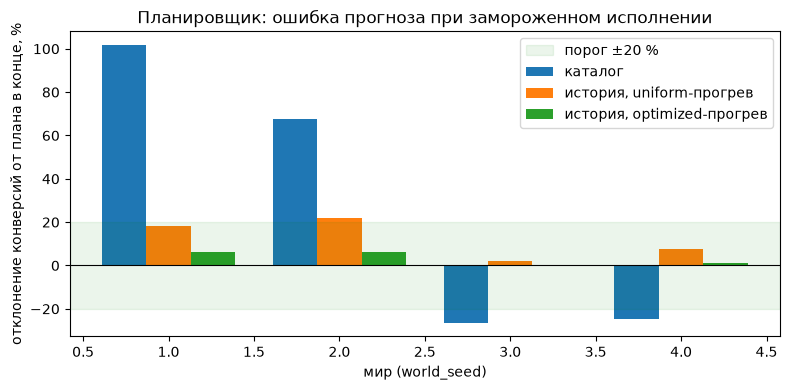

In [3]:
fig, ax = plt.subplots(figsize=(8, 4)); width = 0.26
for i, col in enumerate(table.columns):
    ax.bar(table.index + (i - 1) * width, table[col] * 100, width, label=col)
ax.axhspan(-20, 20, color='green', alpha=0.08, label='порог ±20 %'); ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('мир (world_seed)'); ax.set_ylabel('отклонение конверсий от плана в конце, %')
ax.set_title('Планировщик: ошибка прогноза при замороженном исполнении'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'plan_accuracy.png', dpi=120); plt.show()

По каталогу план промахивается на −25…+100 %: это ширина публичных диапазонов. История трёх кампаний убирает основную ошибку; если прошлые кампании были спланированы оптимально и выкупали сильные каналы глубоко, планнер выучивает и параметры насыщения, и ошибка падает до 0–6 %. Все прогоны с историей в пороге 20 %.

## 2. Трафик-менеджер: сколько KPI даёт лайв-исполнение на том же плане

In [4]:
base = final[final['mode'] == 'frozen'].set_index(['scenario', 'world_seed'])
rows = []
for mode in ['adaptive', 'adaptive_max']:
    sub = final[final['mode'] == mode].set_index(['scenario', 'world_seed'])
    for key, r in sub.iterrows():
        f = base.loc[key]
        rows.append({'scenario': key[0], 'world': key[1], 'mode': mode,
                     'uplift': r.fact_kpi / f.fact_kpi - 1, 'budget_use': r.budget_utilization,
                     'reallocated': r.reallocated_share, 'closeness': abs(r.final_dev_kpi), 'frozen_closeness': abs(f.final_dev_kpi)})
pairs = pd.DataFrame(rows)
summary = (pairs.groupby(['scenario', 'mode'])
           .agg(uplift=('uplift', 'median'), more_kpi=('uplift', lambda x: (x > 0).mean()),
                budget_use=('budget_use', 'median'), reallocated=('reallocated', 'median'), closeness=('closeness', 'median'))
           .reindex(SCENARIOS, level=0))
summary.style.format({'uplift': pct, 'more_kpi': '{:.0%}', 'budget_use': '{:.1%}', 'reallocated': '{:.0%}', 'closeness': '{:.1%}'})

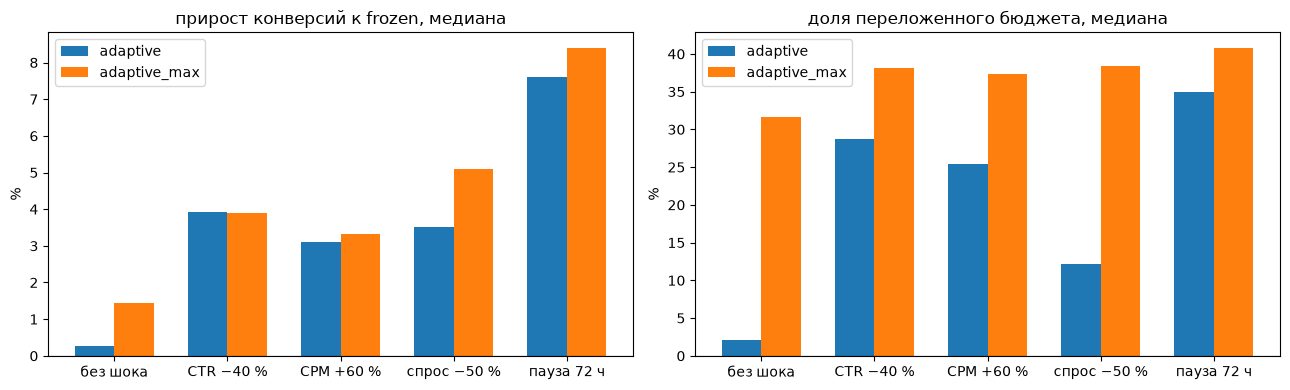

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4)); width = 0.35
for ax, (col, title) in zip(axes, [('uplift', 'прирост конверсий к frozen, медиана'), ('reallocated', 'доля переложенного бюджета, медиана')]):
    for i, m in enumerate(['adaptive', 'adaptive_max']):
        ax.bar([k + (i - 0.5) * width for k in range(len(SCENARIOS))], [summary.loc[(s, m), col] * 100 for s in SCENARIOS], width, label=m)
    ax.set_xticks(range(len(SCENARIOS))); ax.set_xticklabels([SCEN_RU[s] for s in SCENARIOS]); ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('%'); ax.set_title(title); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'live_modes.png', dpi=120); plt.show()

Читать так:
- `adaptive_max` привозит больше конверсий, чем `frozen`, в 19 парах из 20, и больше, чем `adaptive`, в 17 из 20. Прирост при шоках 3–8 %, без шока около 1 %.
- Оба лайв-режима полностью осваивают бюджет при паузе канала и просадке спроса, где `frozen` теряет 6–10 %.
- Цена агрессивности: `adaptive_max` перекладывает 30–40 % бюджета даже без шока, `adaptive` — 2 %.

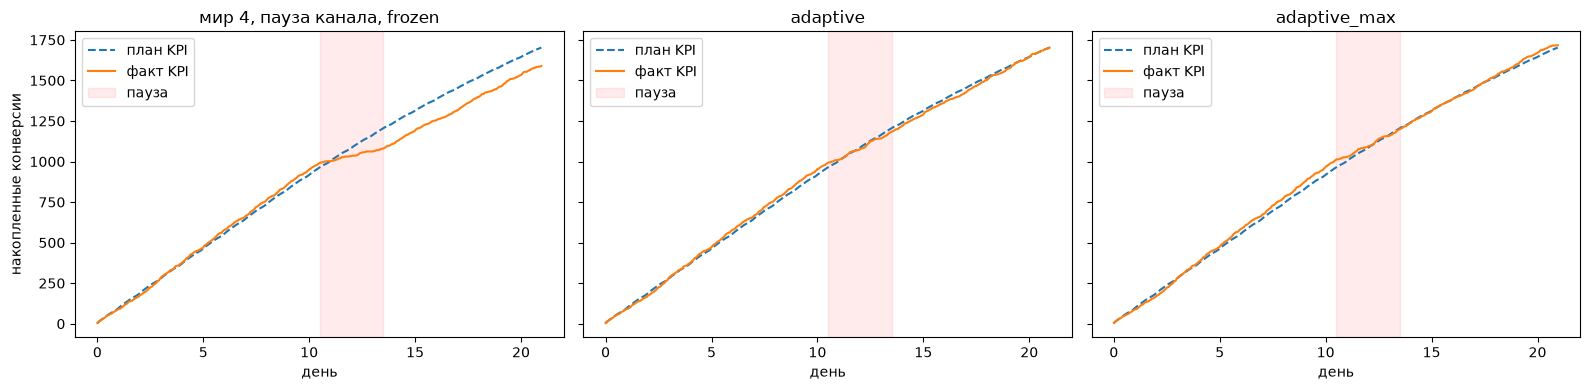

In [6]:
def traj(run_id):
    return pd.read_csv(RESULTS / 'tracking' / 'trajectories' / f'{run_id}.csv')
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (mode, title) in zip(axes, [('frozen', 'мир 4, пауза канала, frozen'), ('adaptive', 'adaptive'), ('adaptive_max', 'adaptive_max')]):
    t = traj(f'w4-c1-h3-pause-{mode}')
    ax.plot(t.hour / 24, t.plan_kpi, '--', label='план KPI'); ax.plot(t.hour / 24, t.fact_kpi, label='факт KPI')
    ax.axvspan(10.5, 13.5, color='red', alpha=0.08, label='пауза'); ax.set_title(title); ax.set_xlabel('день'); ax.legend()
axes[0].set_ylabel('накопленные конверсии')
fig.tight_layout(); fig.savefig(FIG / 'pause_kpi.png', dpi=120); plt.show()

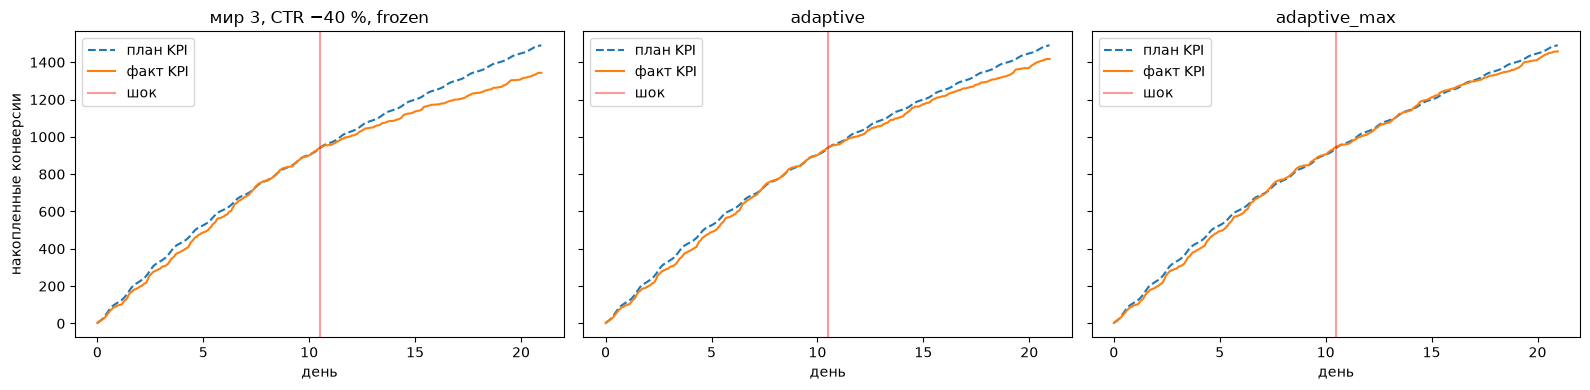

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (mode, title) in zip(axes, [('frozen', 'мир 3, CTR −40 %, frozen'), ('adaptive', 'adaptive'), ('adaptive_max', 'adaptive_max')]):
    t = traj(f'w3-c1-h3-ctr_drop-{mode}')
    ax.plot(t.hour / 24, t.plan_kpi, '--', label='план KPI'); ax.plot(t.hour / 24, t.fact_kpi, label='факт KPI')
    ax.axvline(10.5, color='red', alpha=0.4, label='шок'); ax.set_title(title); ax.set_xlabel('день'); ax.legend()
axes[0].set_ylabel('накопленные конверсии')
fig.tight_layout(); fig.savefig(FIG / 'ctr_drop_kpi.png', dpi=120); plt.show()

## 3. Парные сравнения по мирам: конверсии

In [8]:
by = final.set_index(['scenario', 'world_seed', 'mode'])['fact_kpi'].unstack('mode')[['frozen', 'adaptive', 'adaptive_max']].reindex(SCENARIOS, level=0)
by['план'] = final[final['mode'] == 'frozen'].set_index(['scenario', 'world_seed'])['plan_kpi'].reindex(by.index)
by['adaptive_max − frozen'] = (by['adaptive_max'] / by['frozen'] - 1)
by[['план', 'frozen', 'adaptive', 'adaptive_max', 'adaptive_max − frozen']].style.format({'план': '{:.0f}', 'frozen': '{:.0f}', 'adaptive': '{:.0f}', 'adaptive_max': '{:.0f}', 'adaptive_max − frozen': pct})

## Выводы

1. **Планировщик.** Ошибка прогноза по каталогу — до 2 раз, по истории трёх кампаний — до 6 %. Главное, чему научился планнер, — рынок, а не формулы. Все прогоны с историей в пороге 20 %.
2. **Трафик-менеджер.** `adaptive_max` — основной лайв-алгоритм: больше конверсий, чем замороженный план, в 19 парах из 20, при шоках на 3–8 %, бюджет осваивается полностью. `adaptive` — консервативный вариант для тех, кому важно не переписывать согласованное распределение: почти тот же результат при 2 % переложенного бюджета вместо 30 %.
3. Оба лайв-режима опираются на одно и то же: верный план из истории и калибровку окном, которая видит шок за часы. Без калибровки окном лайв-алгоритм в утренних прогонах проигрывал даже по конверсиям — гонялся за шумом.